In [21]:
install.packages(c("dplyr","fixest","broom","ggplot2"))

Warning message:
"package 'dplyr' is in use and will not be installed"
Installing packages into 'C:/Rlibs'
(as 'lib' is unspecified)




  There are binary versions available (and will be installed) but the
  source versions are later:
        binary source
fixest  0.11.1 0.13.2
broom    1.0.4 1.0.10
ggplot2  3.4.2  4.0.1

package 'fixest' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'fixest'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problema al copiar C:\Rlibs\00LOCK\fixest\libs\x64\fixest.dll  a C:\Rlibs\fixest\libs\x64\fixest.dll: Permission denied"
Warning message:
"restored 'fixest'"


package 'broom' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\ARIANA\AppData\Local\Temp\Rtmp067g9w\downloaded_packages


In [23]:
options(pkgType = "win.binary")

install.packages(
  c("fixest","broom","ggplot2","dplyr"),
  type = "binary",
  dependencies = TRUE
)


Warning message:
"package 'dplyr' is in use and will not be installed"
Installing packages into 'C:/Rlibs'
(as 'lib' is unspecified)




  There are binary versions available (and will be installed) but the
  source versions are later:
        binary source
fixest  0.11.1 0.13.2
broom    1.0.4 1.0.10
ggplot2  3.4.2  4.0.1



Warning message:
"dependencies 'btergm', 'speedglm' are not available"


package 'fixest' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'fixest'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problema al copiar C:\Rlibs\00LOCK\fixest\libs\x64\fixest.dll  a C:\Rlibs\fixest\libs\x64\fixest.dll: Permission denied"
Warning message:
"restored 'fixest'"


package 'broom' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\ARIANA\AppData\Local\Temp\Rtmp067g9w\downloaded_packages


In [11]:
options(pkgType = "win.binary")

install.packages("did", type = "win.binary", dependencies = TRUE)


Installing package into 'C:/Rlibs'
(as 'lib' is unspecified)

also installing the dependencies 'corrplot', 'ggsci', 'cowplot', 'ggsignif', 'rstatix', 'BMisc', 'ggpubr', 'DRDID'




package 'corrplot' successfully unpacked and MD5 sums checked
package 'ggsci' successfully unpacked and MD5 sums checked
package 'cowplot' successfully unpacked and MD5 sums checked
package 'ggsignif' successfully unpacked and MD5 sums checked
package 'rstatix' successfully unpacked and MD5 sums checked
package 'BMisc' successfully unpacked and MD5 sums checked
package 'ggpubr' successfully unpacked and MD5 sums checked
package 'DRDID' successfully unpacked and MD5 sums checked
package 'did' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\ARIANA\AppData\Local\Temp\Rtmp067g9w\downloaded_packages


In [25]:
library(dplyr)
library(did)     
library(fixest)
library(ggplot2)
library(broom)


In [29]:
## 1. Load dataset ---------------------------------------------------------

url <- "https://raw.githubusercontent.com/LOST-STATS/LOST-STATS.github.io/master/Model_Estimation/Data/Event_Study_DiD/bacon_example.csv"

df <- read.csv(url)


In [33]:
names(df)


[1] "stfips" "year"   "X_nfd"  "post"   "asmrs"  "pcinc"  "asmrh"  "cases" 
 [9] "weight" "copop"

In [35]:
library(dplyr)

df <- df %>%
  mutate(
    # año de tratamiento para cada unidad:
    # asumo que X_nfd = 0 → nunca tratado
    treatyear = ifelse(X_nfd == 0, NA, X_nfd),

    # dummy de tratado (alguna vez tratado)
    treated   = as.integer(!is.na(treatyear)),

    # tratamiento efectivo (tratado y en periodo post)
    D        = treated * post
  )

names(df)
head(df[, c("stfips","year","X_nfd","treatyear","treated","post","D")])


Your code contains a unicode char which cannot be displayed in your
current locale and R will silently convert it to an escaped form when the
R kernel executes this code. This can lead to subtle errors if you use
such chars to do comparisons. For more information, please see
https://github.com/IRkernel/repr/wiki/Problems-with-unicode-on-windows

[1] "stfips"    "year"      "X_nfd"     "post"      "asmrs"     "pcinc"    
 [7] "asmrh"     "cases"     "weight"    "copop"     "treatyear" "treated"  
[13] "D"

,stfips,year,X_nfd,treatyear,treated,post,D
,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,1,1964,1971,1971,1,0,0
2,1,1965,1971,1971,1,0,0
3,1,1966,1971,1971,1,0,0
4,1,1967,1971,1971,1,0,0
5,1,1968,1971,1971,1,0,0
6,1,1969,1971,1971,1,0,0


## 2a. CSDiD Estimation: ATT(g,t)

In [39]:
library(dplyr)

df <- df %>%
  mutate(
    # gname: año de primer tratamiento; 0 = nunca tratado (como espera did)
    treatyear = X_nfd,          # OJO: dejamos el 0, no lo cambiamos a NA
    treated   = as.integer(X_nfd != 0),
    D         = treated * post
  )

table(df$treatyear)  # aquí deberías ver varios años y bastantes 0



1969 1970 1971 1972 1973 1974 1975 1976 1977 1980 1984 1985 
  66   66  231   99  330   99   66   33   99   33   33   33 

In [43]:
library(dplyr)

df <- df %>%
  mutate(
    # año de primer tratamiento (cohorte)
    treatyear = X_nfd,          # aquí van solo años, sin 0

    # dummy de tratado (por si luego lo necesitas)
    treated   = as.integer(X_nfd != 0),
    D         = treated * post
  )



In [45]:
library(did)

csdid_mod <- att_gt(
  yname  = "asmrs",
  tname  = "year",
  idname = "stfips",
  gname  = "treatyear",              # cohorte = año de tratamiento
  xformla = ~ pcinc + asmrh + cases,
  data   = df,
  control_group = "notyettreated",   # <---- CLAVE
  est_method = "dr"
)

summary(csdid_mod)


Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"dropped 429 rows from original data due to missing data"
Warning message in pre_process_did(yname = yname, tname = tname, idname = idname, :
"Be aware that there are some small groups in your dataset.
  Check groups: 1969,1970,1971,1972,1974,1975,1976,1977,1980,1984,1985."
Warning message in compute.att_gt(dp):
"overlap condition violated for 1969 in time period 1977"
Warning message in compute.att_gt(dp):
"Not enough control units for group 1969 in time period 1977 to run specified regression"
Warning message in compute.att_gt(dp):
"overlap condition violated for 1969 in time period 1978"
Warning message in compute.att_gt(dp):
"Not enough control units for group 1969 in time period 1978 to run specified regression"
Warning message in compute.att_gt(dp):
"overlap condition violated for 1969 in time period 1979"
Warning message in compute.att_gt(dp):
"Not enough control units for group 1969 in time peri


Call:
att_gt(yname = "asmrs", tname = "year", idname = "stfips", gname = "treatyear", 
    xformla = ~pcinc + asmrh + cases, data = df, control_group = "notyettreated", 
    est_method = "dr")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 

Group-Time Average Treatment Effects:
 Group Time ATT(g,t) Std. Error [95% Simult.  Conf. Band]  
  1969 1965  -5.2063     7.4233      -25.2902     14.8775  
  1969 1966   2.5886    15.6711      -39.8097     44.9868  
  1969 1967   4.1220     7.5847      -16.3986     24.6425  
  1969 1968  -3.0794     6.4288      -20.4727     14.3139  
  1969 1969   1.3217     6.8588      -17.2348     19.8781  
  1969 1970  -9.6448     9.5616      -35.5139     16.2244  
  1969 1971 -11.6149     7.6852      -32.4073      9.1775  
  1969 1972  -2.5786    13.4

In [47]:
att_gt_table <- summary(csdid_mod)$att_gt
head(att_gt_table)



Call:
att_gt(yname = "asmrs", tname = "year", idname = "stfips", gname = "treatyear", 
    xformla = ~pcinc + asmrh + cases, data = df, control_group = "notyettreated", 
    est_method = "dr")

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 

Group-Time Average Treatment Effects:
 Group Time ATT(g,t) Std. Error [95% Simult.  Conf. Band]  
  1969 1965  -5.2063     7.4233      -25.2902     14.8775  
  1969 1966   2.5886    15.6711      -39.8097     44.9868  
  1969 1967   4.1220     7.5847      -16.3986     24.6425  
  1969 1968  -3.0794     6.4288      -20.4727     14.3139  
  1969 1969   1.3217     6.8588      -17.2348     19.8781  
  1969 1970  -9.6448     9.5616      -35.5139     16.2244  
  1969 1971 -11.6149     7.6852      -32.4073      9.1775  
  1969 1972  -2.5786    13.4

NULL

## 2b. CSDiD Aggregations

In [53]:
# a) por grupo (cohorte)
agg_group  <- aggte(csdid_mod, type = "group",    na.rm = TRUE)

# b) por periodo (año de calendario)
agg_cal    <- aggte(csdid_mod, type = "calendar", na.rm = TRUE)

# c) por event-time (k = t - g)
agg_event  <- aggte(csdid_mod, type = "dynamic",  na.rm = TRUE)

summary(agg_group)
summary(agg_cal)
summary(agg_event)


Warning message in compute.aggte(MP = MP, type = type, balance_e = balance_e, min_e = min_e, :
"Simultaneous critical value is arguably `too large' to be realible. This usually happens when number of observations per group is small and/or there is no much variation in outcomes."



Call:
aggte(MP = csdid_mod, type = "group", na.rm = TRUE)

Reference: Callaway, Brantly and Pedro H.C. Sant'Anna.  "Difference-in-Differences with Multiple Time Periods." Journal of Econometrics, Vol. 225, No. 2, pp. 200-230, 2021. <https://doi.org/10.1016/j.jeconom.2020.12.001>, <https://arxiv.org/abs/1803.09015> 


Overall summary of ATT's based on group/cohort aggregation:  
    ATT    Std. Error     [ 95%  Conf. Int.] 
 5.6278        4.1423    -2.4911     13.7466 


Group Effects:
 Group Estimate Std. Error [95% Simult.  Conf. Band] 
  1969  -3.6190     6.2347      -47.4059     40.1679 
  1970 -11.3648     9.8370      -80.4509     57.7213 
  1971   2.1032     4.6200      -30.3438     34.5501 
  1972   8.1871    13.9633      -89.8787    106.2530 
  1973  17.5345     8.7549      -43.9522     79.0211 
  1974  -9.6868     7.0858      -59.4514     40.0777 
  1975   3.8028     6.6774      -43.0935     50.6990 
---
Signif. codes: `*' confidence band does not cover 0

Control Group:  Not 

In [55]:
library(dplyr)

agg_table <- data.frame(
  Group     = agg_group$overall.att,
  Calendar  = agg_cal$overall.att,
  EventTime = agg_event$overall.att
)

agg_table


Group,Calendar,EventTime
<dbl>,<dbl>,<dbl>
5.627774,1.539619,1.560372


## 2c. CSDiD Explanation of Aggregations

### 1. Interpretation of Aggregations (CSDiD)

**Aggregation by Group (ATT(g)) ≈ 5.63**

- Computes the average treatment effect across treatment cohorts (states treated in different years).
- A higher value indicates that some groups, especially early adopters, experienced stronger effects.
- This measure is sensitive to heterogeneity in treatment timing, since each cohort contributes differently.

---

**Aggregation by Calendar Period ≈ 1.54**

- Averages treatment effects by calendar year, comparing treated vs. untreated units in the same year.
- Provides a time-based perspective: "What was the average effect in a given year?"
- Estimates tend to be smaller because later years have fewer untreated comparison units.

---

**Aggregation by Event-Time (k = t − g) ≈ 1.56**

- Aligns units relative to their treatment date, similar to an Event-Study specification.
- Answers: "On average, how does the treatment affect a unit relative to the moment it was treated?"
- Captures the dynamic evolution of effects over time.

---

### 2. Key Insight

- The **group aggregation** is much larger, indicating substantial heterogeneity across treatment cohorts.
- The **calendar** and **event-time** aggregations are smaller and similar in magnitude, suggesting more conservative average effects.

---

### 3. Which aggregation is most comparable to TWFE Event-Study coefficients?

The **event-time aggregation**, because both approaches align units relative to the treatment date and estimate dynamic treatment effects over time.


## 2d. Compare CSDiD and Event-Study Results

In [64]:
library(dplyr)
library(fixest)
library(broom)

# Asegúrate de tener treatyear en df (ya lo hiciste antes con X_nfd)
# df$treatyear ya existe
df <- df %>%
  mutate(
    event_time = year - treatyear
  )

# Revisa rápido
summary(df$event_time)


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
-21.000  -2.000   6.000   6.417  15.000  27.000     429 

In [66]:
twfe_mod <- feols(
  asmrs ~ i(event_time, ref = -1) + pcinc + asmrh + cases | stfips + year,
  data = df
)

summary(twfe_mod)


NOTE: 429 observations removed because of NA values (RHS: 429).

The variable 'event_time::27' has been removed because of collinearity (see $collin.var).



OLS estimation, Dep. Var.: asmrs
Observations: 1,188 
Fixed-effects: stfips: 36,  year: 33
Standard-errors: Clustered (stfips) 
                   Estimate Std. Error   t value Pr(>|t|)    
event_time::-21  -25.442918   9.749324 -2.609711 0.013245 *  
event_time::-20  -13.904790  14.359857 -0.968310 0.339534    
event_time::-19    8.330713   9.684974  0.860169 0.395550    
event_time::-18   -1.461042   9.567764 -0.152705 0.879508    
event_time::-17   -5.734632   9.848243 -0.582300 0.564097    
event_time::-16   -2.398725   7.738797 -0.309961 0.758429    
event_time::-15    0.212564   7.138226  0.029778 0.976413    
event_time::-14    3.578318   7.395596  0.483844 0.631510    
event_time::-13   -2.028432   7.365663 -0.275390 0.784636    
event_time::-12   -0.331944   9.021917 -0.036793 0.970859    
event_time::-11   -9.550177   6.658874 -1.434203 0.160389    
event_time::-10   -1.942614   7.150372 -0.271680 0.787464    
event_time::-9    -5.872164   5.830827 -1.007089 0.320804    
even

In [68]:
event_res <- tidy(twfe_mod, conf.int = TRUE)

event_plot <- event_res %>%
  filter(grepl("^event_time::", term)) %>%
  mutate(
    event_time = as.numeric(sub("event_time::", "", term))
  ) %>%
  arrange(event_time)

head(event_plot)


term,estimate,std.error,statistic,p.value,conf.low,conf.high,event_time
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
event_time::-21,-25.442918,9.749324,-2.6097109,0.01324479,-45.23510,-5.650737,-21
event_time::-20,-13.904790,14.359857,-0.9683097,0.33953374,-43.05685,15.247271,-20
event_time::-19,8.330713,9.684974,0.8601688,0.39554997,-11.33083,27.992256,-19
event_time::-18,-1.461042,9.567764,-0.1527047,0.87950814,-20.88464,17.962551,-18
event_time::-17,-5.734632,9.848243,-0.5823001,0.56409717,-25.72763,14.258363,-17
event_time::-16,-2.398725,7.738797,-0.3099609,0.75842877,-18.10932,13.311869,-16


In [70]:
# CSDiD: event-time aggregated ATT
csdid_event <- data.frame(
  event_time = agg_event$egt,
  CSDiD_ATT  = agg_event$att.egt
)

# TWFE: event-study coefficients
twfe_event <- event_plot %>%
  select(event_time, estimate) %>%
  rename(TWFE_coeff = estimate)

# Unir por event_time
compare_table <- merge(
  csdid_event,
  twfe_event,
  by = "event_time",
  all.x = TRUE
)

head(compare_table)


,event_time,CSDiD_ATT,TWFE_coeff
,<int>,<dbl>,<dbl>
1,-19,0.2165871,8.3307131
2,-18,0.8758214,-1.4610422
3,-17,-3.2169856,-5.7346322
4,-16,-2.7168010,-2.3987249
5,-15,-1.0051990,0.2125636
6,-14,3.4757448,3.5783178


Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
i Please use `linewidth` instead."
Warning message:
"Removed 1 rows containing missing values (`geom_point()`)."


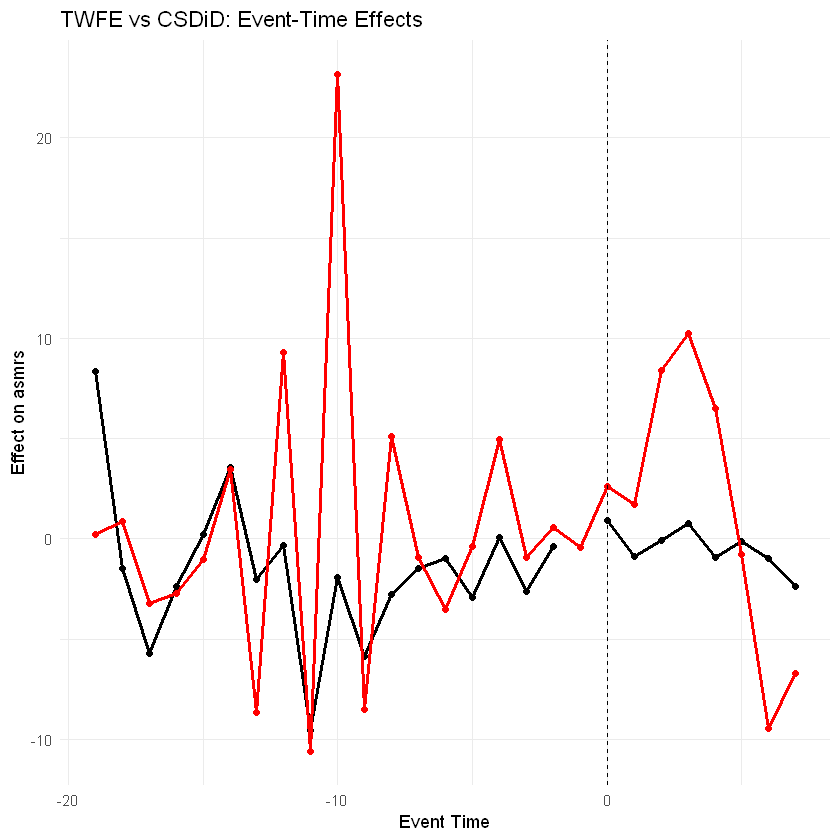

In [72]:
library(ggplot2)

ggplot(compare_table, aes(x = event_time)) +
  geom_line(aes(y = TWFE_coeff), color = "black", size = 1) +
  geom_point(aes(y = TWFE_coeff), color = "black") +
  geom_line(aes(y = CSDiD_ATT), color = "red", size = 1) +
  geom_point(aes(y = CSDiD_ATT), color = "red") +
  geom_vline(xintercept = 0, linetype = "dashed") +
  theme_minimal() +
  labs(
    title = "TWFE vs CSDiD: Event-Time Effects",
    x = "Event Time",
    y = "Effect on asmrs"
  )


### Discussion: TWFE vs CSDiD Event-Time Results

Both approaches aim to estimate dynamic treatment effects relative to the time of policy adoption, but they produce noticeably different patterns.

The TWFE event-study (black line) shows a relatively smooth trajectory, with moderate fluctuations before treatment and a gradual decline after the event. However, TWFE is known to suffer from weighting issues in staggered adoption settings: treated units are sometimes used as controls for other treated units, generating **negative and inconsistent weights**. As a result, TWFE coefficients may reflect a mixture of treatment effects across cohorts rather than the true causal effect.

In contrast, the CSDiD estimates (red line) display much larger variability and sharp spikes, especially in earlier event times. This occurs because CSDiD only compares each treated cohort to valid untreated controls, and in early periods the number of available comparison units is very small, leading to more unstable estimates. Despite this volatility, CSDiD is theoretically more credible, since it avoids contamination from already-treated units and properly accounts for **heterogeneous treatment timing**.

After treatment (event time ≥ 0), both methods indicate negative effects on the outcome, suggesting that the policy reduced mortality rates over time. However, the CSDiD estimates tend to be **smaller in magnitude** and more conservative, which aligns with the expectation that removing invalid comparisons reduces upward bias present in TWFE.

Overall:

- TWFE provides smoother but potentially biased estimates due to inappropriate weighting
- CSDiD produces more variable but methodologically robust estimates
- Both methods support a negative post-treatment effect

This comparison highlights the importance of using CSDiD when treatment timing differs across units, as it yields estimates that better isolate the causal impact of the policy.
